In [1]:
!pip install -q huggingface_hub transformers torch accelerate sentence-transformers scikit-learn scipy pandas matplotlib seaborn tqdm

In [2]:
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy.stats import norm as scipy_norm
from sentence_transformers import SentenceTransformer
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    LogitsProcessor,
    LogitsProcessorList,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

RESULTS_DIR = Path("results")
OUTDIR = Path("output")
RESULTS_DIR.mkdir(exist_ok=True)
OUTDIR.mkdir(exist_ok=True)

## 1. Watermarking — Context-Hash Green-List (KGW-style)
Unchanged: embeds via logits bias, detects via z-score / one-sided p-value.

In [ ]:
class WatermarkLogitsProcessor(LogitsProcessor):
    def __init__(self, vocab_size: int, gamma: float = 0.5, delta: float = 2.0, key: int = 1234):
        self.vocab_size = vocab_size
        self.gamma = gamma
        self.delta = delta
        self.key = key

    def _get_green_ids(self, prev_token: int):
        rng = np.random.default_rng(self.key + int(prev_token))
        perm = rng.permutation(self.vocab_size)
        return perm[: int(self.gamma * self.vocab_size)]

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor) -> torch.FloatTensor:
        for i in range(input_ids.shape[0]):
            prev_token = input_ids[i, -1].item()
            green_ids = self._get_green_ids(prev_token)
            scores[i, green_ids] += self.delta
        return scores


class WatermarkDetector:
    def __init__(self, tokenizer, gamma: float = 0.5, key: int = 1234):
        self.tokenizer = tokenizer
        self.vocab_size = tokenizer.vocab_size
        self.gamma = gamma
        self.key = key

    def detect(self, text: str) -> dict:
        token_ids = self.tokenizer.encode(text, add_special_tokens=False)
        n = len(token_ids) - 1
        if n < 1:
            return {"green_fraction": 0.0, "z_score": 0.0, "p_value": 1.0, "n_tokens": 0}

        green_count = 0
        for i in range(1, len(token_ids)):
            prev_token = token_ids[i - 1]
            curr_token = token_ids[i]
            rng = np.random.default_rng(self.key + int(prev_token))
            perm = rng.permutation(self.vocab_size)
            green_set = set(perm[: int(self.gamma * self.vocab_size)])
            if curr_token in green_set:
                green_count += 1

        frac = green_count / n
        mean = self.gamma * n
        std = np.sqrt(n * self.gamma * (1 - self.gamma))
        z = (green_count - mean) / std if std > 0 else 0.0
        p_value = float(scipy_norm.sf(z))
        return {"green_fraction": frac, "z_score": float(z), "p_value": p_value, "n_tokens": n}

## 2. Fingerprinting — Cross-Model Softmax Calibration (no threshold)

`build_gallery` is unchanged (probe responses -> concatenated embedding). `CrossModelFingerprintScorer`
is new: it holds every candidate model's gallery and scores a text by softmax over cosine
similarities to all of them, returning both the probability assigned to the true model
(continuous `fp_score`) and whether the top-1 match is correct (binary `fp_dec`).

In [ ]:
class Fingerprinter:
    def __init__(self, probe_prompts, embed_model_name="all-MiniLM-L6-v2"):
        self.probes = probe_prompts
        self.embedder = SentenceTransformer(embed_model_name)

    def build_gallery(self, generate_fn):
        responses = [generate_fn(p).strip() for p in self.probes]
        embs = self.embedder.encode(responses, normalize_embeddings=True)  # (n_probes, dim)
        return embs.mean(axis=0)  # average, then you can re-normalize if you want unit length


class CrossModelFingerprintScorer:
    """Scores text against ALL candidate galleries via softmax -- no fixed similarity threshold.
    fp_score  = softmax probability assigned to the TRUE source model (continuous, in [0,1])
    fp_dec    = 1 if the argmax (nearest) gallery is the true model (temperature-independent)
    """

    def __init__(self, galleries: dict, embedder: SentenceTransformer, temperature: float = 0.05):
        self.model_names = list(galleries.keys())
        self.gallery_matrix = np.stack([galleries[m] for m in self.model_names])  # (n_models, dim)
        self.embedder = embedder
        self.temperature = temperature

    def score(self, text: str, true_model_name: str) -> dict:
        emb = self.embedder.encode(text, normalize_embeddings=True)
        sims = self.gallery_matrix @ emb  # (n_models,)
        logits = sims / self.temperature
        probs = np.exp(logits - logits.max())
        probs = probs / probs.sum()

        true_idx = self.model_names.index(true_model_name)
        top1_idx = int(np.argmax(sims))
        return {
            "fp_score": float(probs[true_idx]),
            "fp_dec": int(top1_idx == true_idx),
            "top1_pred_model": self.model_names[top1_idx],
            "top1_sim": float(sims[top1_idx]),
        }

## 3. Decision Fusion — Soft (Probabilistic) OR

```
norm_wm = clip(z_score / z_ref, 0, 1)     # z_ref = 4 ("clearly watermarked" reference)
norm_fp = fp_score                        # already a calibrated probability in [0,1]
fused   = norm_wm + norm_fp - norm_wm * norm_fp
```

Both terms are now well-scaled probabilities/normalized statistics, so neither one structurally
dominates or collapses to zero — unlike v1's weighted-linear rule or v2's threshold-clipped FP.

In [ ]:
def fuse_decision(wm_stats: dict, fp_stats: dict, z_ref: float = 4.0, wm_alpha: float = 0.01):
    norm_wm = max(0.0, min(1.0, wm_stats["z_score"] / z_ref))
    norm_fp = max(0.0, min(1.0, fp_stats["fp_score"]))

    fused_score = norm_wm + norm_fp - (norm_wm * norm_fp)  # soft-OR fusion

    return {
        "wm_dec": int(wm_stats["p_value"] < wm_alpha),
        "fp_dec": fp_stats["fp_dec"],
        "norm_wm": norm_wm,
        "norm_fp": norm_fp,
        "fused_score": float(fused_score),
        "decision": bool(fused_score >= 0.5),
    }

## 4. Attacks Module

`sentence_reorder` (shuffles sentence order) is the honest name for what was previously
mislabeled `"paraphrase"` — it is not semantic paraphrasing; list true paraphrase-attack
robustness as future work in the paper.

In [ ]:
def sentence_reorder(text):
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    if len(sentences) > 1:
        random.shuffle(sentences)
    return ". ".join(sentences) + "." if sentences else text


def truncate_text(text, ratio=0.7):
    words = text.split()
    k = max(1, int(len(words) * ratio))
    return " ".join(words[:k])


def summarize_naive(text, ratio=0.5):
    words = text.split()
    k = max(1, int(len(words) * ratio))
    return " ".join(words[:k])


def word_noise(text, noise_rate=0.1):
    words = text.split()
    if len(words) < 5:
        return text
    n = max(1, int(len(words) * noise_rate))
    idx = random.sample(range(len(words)), n)
    for i in idx:
        words[i] = "[MASK]"
    return " ".join(words)


def apply_attack(text, attack_type):
    if attack_type == "none":
        return text
    if attack_type == "sentence_reorder":
        return sentence_reorder(text)
    if attack_type == "truncate":
        return truncate_text(text, 0.7)
    if attack_type == "summarize":
        return summarize_naive(text, 0.5)
    if attack_type == "noise":
        return word_noise(text, 0.1)
    return text


ATTACKS = ["none", "sentence_reorder", "truncate", "summarize", "noise"]

## 5. Model Loading + Perplexity

In [ ]:
def load_model(model_name: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else (
        torch.float16 if torch.cuda.is_available() else torch.float32
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=dtype, device_map="auto" if torch.cuda.is_available() else None
    )
    if not torch.cuda.is_available():
        model = model.to("cpu")
    model.eval()
    return model, tokenizer


def compute_perplexity(model, tokenizer, text: str) -> float:
    if not text.strip():
        return float("nan")
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    input_ids = enc["input_ids"]
    if input_ids.shape[1] < 2:
        return float("nan")
    with torch.inference_mode():
        out = model(input_ids, labels=input_ids)
    return float(torch.exp(out.loss).item())

## 6. Models

Add/remove freely — everything downstream works for any subset. Keep this list modest for a
multi-day timeline; add a large model (e.g. Mistral-7B) last, once the pipeline is confirmed
working, since it dominates runtime.

In [ ]:
MODELS = [
    "gpt2",
    "distilgpt2",
    "facebook/opt-125m",
    "EleutherAI/gpt-neo-125M",
    "Qwen/Qwen2.5-0.5B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.2",
]

NUM_SAMPLES = 60     # generations per model before attacks (x5 attacks x2 WM/control = 10x rows)
BATCH_SIZE = 10
FP_TEMPERATURE = 0.05  # softmax temperature; affects only continuous fp_score smoothness,
                        # NOT the top-1 decision (fp_dec), so it does not need calibration.

## 7. Step A — Build every model's gallery up front

This is the key structural change from v2/the add-on: galleries for **all** models must exist
*before* generation starts, since every row is scored against all of them.

In [9]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")
fingerprinter = Fingerprinter(
    probe_prompts=[
        "Describe how to brew tea briefly.",
        "Explain a short analogy about clouds.",
        "Write three short sentences about cooking rice.",
    ],
    embed_model_name="all-MiniLM-L6-v2",
)
fingerprinter.embedder = embedder  # reuse the single loaded embedder

galleries = {}
for m in MODELS:
    print(f"Building gallery for {m}...")
    model, tokenizer = load_model(m)

    def generate_single(prompt, _model=model, _tok=tokenizer):
        inputs = _tok(prompt, return_tensors="pt").to(_model.device)
        out = _model.generate(**inputs, max_new_tokens=64, do_sample=True, pad_token_id=_tok.pad_token_id)
        return _tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    galleries[m] = fingerprinter.build_gallery(generate_single)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

np.savez(OUTDIR / "galleries.npz", **{k.replace("/", "_"): v for k, v in galleries.items()})
scorer = CrossModelFingerprintScorer(galleries, embedder, temperature=FP_TEMPERATURE)
print(f"Built {len(galleries)} galleries.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Building gallery for gpt2...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Building gallery for Qwen/Qwen2.5-0.5B-Instruct...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Building gallery for mistralai/Mistral-7B-Instruct-v0.2...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Built 6 galleries.


## 8. Step B — Experiment pipeline

Each prompt generates both a watermarked and a control (unwatermarked) version. Every generated
text is scored against **all** galleries via the softmax scorer above, so `fp_score`/`fp_dec`
reflect real cross-model discrimination, not a self-similarity check.

In [10]:
def run_robustness_experiment(model_name, scorer, num_samples=60, batch_size=10):
    print(f"--- Running: {model_name} ---")
    model, tokenizer = load_model(model_name)

    wm_processor = WatermarkLogitsProcessor(tokenizer.vocab_size, gamma=0.5, delta=2.0)
    logits_processor = LogitsProcessorList([wm_processor])
    detector = WatermarkDetector(tokenizer, gamma=0.5)

    prompts = [
        "Explain the key principles of cloud computing.",
        "What are the primary differences between TCP and UDP?",
        "Summarize the process of cellular respiration.",
        "Discuss the economic impact of artificial intelligence.",
        "How do optical fibers transmit data over long distances?",
    ] * (num_samples // 5 + 1)
    prompts = prompts[:num_samples]

    results = []
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch_prompts = prompts[i:i + batch_size]
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(model.device)
        input_len = inputs["input_ids"].shape[1]

        for is_watermarked in (True, False):
            t0 = time.time()
            with torch.inference_mode():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=128,
                    do_sample=True,
                    temperature=0.7,
                    logits_processor=logits_processor if is_watermarked else None,
                    pad_token_id=tokenizer.pad_token_id,
                )
            latency = ((time.time() - t0) * 1000) / len(batch_prompts)

            for idx in range(len(batch_prompts)):
                gen_tokens = outputs[idx][input_len:]
                gen_text = tokenizer.decode(gen_tokens, skip_special_tokens=True)
                ppl = compute_perplexity(model, tokenizer, gen_text)

                for attack in ATTACKS:
                    attacked_text = apply_attack(gen_text, attack)

                    wm_stats = detector.detect(attacked_text)
                    fp_stats = scorer.score(attacked_text, true_model_name=model_name)
                    fused = fuse_decision(wm_stats, fp_stats)

                    results.append({
                        "model_name": model_name,
                        "sample_id": i + idx,
                        "is_watermarked": is_watermarked,
                        "attack": attack,
                        "attacked_text": attacked_text,
                        "wm_z": wm_stats["z_score"],
                        "wm_p": wm_stats["p_value"],
                        "fp_score": fp_stats["fp_score"],
                        "top1_pred_model": fp_stats["top1_pred_model"],
                        "norm_wm": fused["norm_wm"],
                        "norm_fp": fused["norm_fp"],
                        "fused_score": fused["fused_score"],
                        "wm_dec": fused["wm_dec"],
                        "fp_dec": fused["fp_dec"],
                        "hybrid_dec": int(fused["decision"]),
                        "perplexity": ppl if attack == "none" else float("nan"),
                        "latency_ms": latency,
                    })

    safe_name = model_name.replace("/", "_")
    out_path = RESULTS_DIR / f"results_{safe_name}.jsonl"
    with open(out_path, "w") as fh:
        for r in results:
            fh.write(json.dumps(r) + "\n")
    print(f"{model_name}: {len(results)} rows -> {out_path}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return results


for m in MODELS:
    run_robustness_experiment(m, scorer, num_samples=NUM_SAMPLES, batch_size=BATCH_SIZE)

--- Running: gpt2 ---


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████| 6/6 [03:40<00:00, 36.78s/it]


gpt2: 600 rows -> results/results_gpt2.jsonl
--- Running: distilgpt2 ---


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

100%|████████████████████████████████████████████| 6/6 [10:31<00:00, 105.23s/it]


Qwen/Qwen2.5-0.5B-Instruct: 600 rows -> results/results_Qwen_Qwen2.5-0.5B-Instruct.jsonl
--- Running: mistralai/Mistral-7B-Instruct-v0.2 ---


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████| 6/6 [03:05<00:00, 30.87s/it]

mistralai/Mistral-7B-Instruct-v0.2: 600 rows -> results/results_mistralai_Mistral-7B-Instruct-v0.2.jsonl


## 9. Aggregation & Metrics

In [11]:
def load_jsonl(path):
    rows = []
    with open(path, "r") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

files = sorted(RESULTS_DIR.glob("results_*.jsonl"))
assert files, "No result files found -- run the experiment cell above first."
all_df = pd.concat([load_jsonl(f) for f in files], ignore_index=True)
all_df.to_csv(OUTDIR / "all_results.csv", index=False)
print(f"Loaded {len(all_df)} rows across {all_df['model_name'].nunique()} models.")
print("fp_score summary (should NOT be all-zero/all-clipped now):")
print(all_df["fp_score"].describe())

Loaded 3600 rows across 6 models.
fp_score summary (should NOT be all-zero/all-clipped now):
count    3600.000000
mean        0.200327
std         0.115165
min         0.004873
25%         0.109969
50%         0.181523
75%         0.266621
max         0.677504
Name: fp_score, dtype: float64


In [12]:
# --- Table A: decision / detection rates, WM-only vs FP-only (top-1) vs Hybrid ---
tableA = (
    all_df.groupby(["model_name", "attack", "is_watermarked"])
    .agg(
        n=("hybrid_dec", "count"),
        wm_rate=("wm_dec", "mean"),
        fp_rate=("fp_dec", "mean"),
        hybrid_rate=("hybrid_dec", "mean"),
        wm_mean_z=("wm_z", "mean"),
        fp_mean_prob=("fp_score", "mean"),
        fused_mean=("fused_score", "mean"),
    )
    .reset_index()
)
tableA.to_csv(OUTDIR / "tableA_decision_rates_wm_fp_hybrid.csv", index=False)
tableA

,model_name,attack,is_watermarked,n,wm_rate,fp_rate,hybrid_rate,wm_mean_z,fp_mean_prob,fused_mean
0,EleutherAI/gpt-neo-125M,noise,False,60,0.066667,0.933333,0.416667,0.637952,0.320139,0.472630
1,EleutherAI/gpt-neo-125M,noise,True,60,1.000000,0.866667,1.000000,5.904471,0.323879,0.994796
2,EleutherAI/gpt-neo-125M,none,False,60,0.133333,0.200000,0.283333,0.562373,0.183412,0.368786
3,EleutherAI/gpt-neo-125M,none,True,60,1.000000,0.133333,1.000000,7.993084,0.173484,0.997223
4,EleutherAI/gpt-neo-125M,sentence_reorder,False,60,0.033333,0.183333,0.166667,0.157796,0.177766,0.311279
5,EleutherAI/gpt-neo-125M,sentence_reorder,True,60,1.000000,0.116667,1.000000,7.267190,0.169736,0.997223
6,EleutherAI/gpt-neo-125M,summarize,False,60,0.016667,0.233333,0.150000,0.087538,0.183408,0.292160
7,EleutherAI/gpt-neo-125M,summarize,True,60,0.983333,0.133333,1.000000,4.960757,0.168959,0.978410
8,EleutherAI/gpt-neo-125M,truncate,False,60,0.016667,0.200000,0.066667,0.007640,0.175483,0.273238
9,EleutherAI/gpt-neo-125M,truncate,True,60,0.983333,0.083333,1.000000,5.884179,0.165081,0.989334


In [13]:
# --- Table B: AUROC + TPR@fixed-FPR, WM-only vs FP-only vs Hybrid ---
def tpr_at_fpr(y_true, y_score, target_fpr):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    idx = np.searchsorted(fpr, target_fpr, side="right") - 1
    idx = max(0, idx)
    return float(tpr[idx])

def roc_metrics_for(df, score_col, label):
    rows = []
    for (model, attack), g in df.groupby(["model_name", "attack"]):
        y = g["is_watermarked"].astype(int).values
        s = g[score_col].values
        if len(set(y)) < 2:
            continue
        rows.append({
            "model_name": model, "attack": attack, "metric": label,
            "auroc": roc_auc_score(y, s),
            "tpr_at_fpr01": tpr_at_fpr(y, s, 0.01),
            "tpr_at_fpr05": tpr_at_fpr(y, s, 0.05),
        })
    return pd.DataFrame(rows)

tableB = pd.concat([
    roc_metrics_for(all_df, "wm_z", "WM-only"),
    roc_metrics_for(all_df, "fp_score", "FP-only"),
    roc_metrics_for(all_df, "fused_score", "Hybrid"),
], ignore_index=True)
tableB.to_csv(OUTDIR / "tableB_auroc_tpr_at_fpr.csv", index=False)
tableB

,model_name,attack,metric,auroc,tpr_at_fpr01,tpr_at_fpr05
0,EleutherAI/gpt-neo-125M,noise,WM-only,0.999444,0.983333,1.000000
1,EleutherAI/gpt-neo-125M,none,WM-only,1.000000,1.000000,1.000000
2,EleutherAI/gpt-neo-125M,sentence_reorder,WM-only,1.000000,1.000000,1.000000
3,EleutherAI/gpt-neo-125M,summarize,WM-only,0.999722,0.983333,1.000000
4,EleutherAI/gpt-neo-125M,truncate,WM-only,0.999722,0.983333,1.000000
...,...,...,...,...,...,...
85,mistralai/Mistral-7B-Instruct-v0.2,noise,Hybrid,0.902500,0.383333,0.600000
86,mistralai/Mistral-7B-Instruct-v0.2,none,Hybrid,0.925833,0.316667,0.616667
87,mistralai/Mistral-7B-Instruct-v0.2,sentence_reorder,Hybrid,0.900556,0.366667,0.616667
88,mistralai/Mistral-7B-Instruct-v0.2,summarize,Hybrid,0.847500,0.066667,0.550000


**Note on interpreting Table B's FP-only row:** unlike v2, `fp_score` here is no longer
expected to sit near AUROC=0.5, because it now measures cross-model discrimination (is this
model's gallery a better match than the others'), which correlates with whether the text is
"typical" of that model at all -- watermarking can subtly shift token distributions, which may
show up here too. Report whatever the data actually shows rather than assuming either outcome.

In [14]:
# --- Table C: perplexity (quality cost), watermarked vs control ---
ppl_df = all_df[all_df["attack"] == "none"].dropna(subset=["perplexity"])
tableC = (
    ppl_df.groupby(["model_name", "is_watermarked"])["perplexity"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
tableC.to_csv(OUTDIR / "tableC_perplexity_quality_cost.csv", index=False)
tableC

,model_name,is_watermarked,mean,std,count
0,EleutherAI/gpt-neo-125M,False,5.993404,1.717649,60
1,EleutherAI/gpt-neo-125M,True,5.906516,2.126843,60
2,Qwen/Qwen2.5-0.5B-Instruct,False,2.801136,0.507183,60
3,Qwen/Qwen2.5-0.5B-Instruct,True,3.756133,0.945878,60
4,distilgpt2,False,43.893459,121.034522,31
5,distilgpt2,True,11.268272,8.677778,22
6,facebook/opt-125m,False,7.627387,5.637499,59
7,facebook/opt-125m,True,7.704054,3.401761,60
8,gpt2,False,7.414583,2.891282,59
9,gpt2,True,8.176027,3.156912,56


In [15]:
# --- Table D: top-1 identification accuracy (threshold-free FP-only metric) ---
tableD = (
    all_df.groupby(["model_name", "attack"])["fp_dec"]
    .mean()
    .reset_index()
    .rename(columns={"fp_dec": "top1_accuracy"})
)
tableD.to_csv(OUTDIR / "tableD_top1_accuracy.csv", index=False)
tableD

,model_name,attack,top1_accuracy
0,EleutherAI/gpt-neo-125M,noise,0.900000
1,EleutherAI/gpt-neo-125M,none,0.166667
2,EleutherAI/gpt-neo-125M,sentence_reorder,0.150000
3,EleutherAI/gpt-neo-125M,summarize,0.183333
4,EleutherAI/gpt-neo-125M,truncate,0.141667
5,Qwen/Qwen2.5-0.5B-Instruct,noise,0.000000
6,Qwen/Qwen2.5-0.5B-Instruct,none,0.250000
7,Qwen/Qwen2.5-0.5B-Instruct,sentence_reorder,0.283333
8,Qwen/Qwen2.5-0.5B-Instruct,summarize,0.316667
9,Qwen/Qwen2.5-0.5B-Instruct,truncate,0.308333


In [16]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

embedder = SentenceTransformer("all-MiniLM-L6-v2")

# --- load the mean-pooled galleries you already saved ---
gz = np.load(OUTDIR / "galleries.npz")
model_order = MODELS  # same order used when building galleries.npz
gallery_matrix = np.stack([gz[m.replace("/", "_")] for m in model_order])  # (6, dim)

center = gallery_matrix.mean(axis=0)

def center_and_renorm(mat, c):
    out = mat - c
    return out / np.linalg.norm(out, axis=-1, keepdims=True)

gallery_matrix_c = center_and_renorm(gallery_matrix, center)

def rescore_centered(text, true_model_name, temperature=0.05):
    emb = embedder.encode(text, normalize_embeddings=True)
    emb_c = (emb - center)
    emb_c = emb_c / np.linalg.norm(emb_c)
    sims = gallery_matrix_c @ emb_c
    logits = sims / temperature
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()
    true_idx = model_order.index(true_model_name)
    top1_idx = int(np.argmax(sims))
    return {
        "fp_score_centered": float(probs[true_idx]),
        "fp_dec_centered": int(top1_idx == true_idx),
        "top1_pred_model_centered": model_order[top1_idx],
    }

# Re-score every row already in all_df (no LLM calls — just SentenceTransformer
# forward passes, fast even on CPU for ~3,600 short strings).
records = []
for row in tqdm(all_df.itertuples(index=False), total=len(all_df)):
    records.append(rescore_centered(row.attacked_text, row.model_name))
centered_df = pd.DataFrame(records)
all_df_centered = pd.concat([all_df.reset_index(drop=True), centered_df], axis=1)

# Recompute fused score with the centered fingerprint score, keeping norm_wm as-is.
all_df_centered["norm_fp_centered"] = all_df_centered["fp_score_centered"].clip(0, 1)
all_df_centered["fused_score_centered"] = (
    all_df_centered["norm_wm"] + all_df_centered["norm_fp_centered"]
    - all_df_centered["norm_wm"] * all_df_centered["norm_fp_centered"]
)

# Sanity check: does the attractor bias shrink?
none_wm_c = all_df_centered[(all_df_centered.attack == "none") & (all_df_centered.is_watermarked == True)]
print("Centered top-1 prediction share (should be closer to 16.7% each):")
print((none_wm_c["top1_pred_model_centered"].value_counts(normalize=True) * 100).round(1))


class FingerprinterPerProbe:
    def __init__(self, probe_prompts, embed_model_name="all-MiniLM-L6-v2"):
        self.probes = probe_prompts
        self.embedder = SentenceTransformer(embed_model_name)

    def build_gallery(self, generate_fn):
        responses = [generate_fn(p).strip() for p in self.probes]
        embs = self.embedder.encode(responses, normalize_embeddings=True)  # (3, dim)
        return embs  # <-- keep all 3, do NOT average yet


class CrossModelFingerprintScorerPerProbe:
    """Scores by averaging cosine similarity across each candidate's probe set,
    instead of comparing against one pre-averaged gallery vector."""

    def __init__(self, galleries: dict, embedder, temperature: float = 0.05):
        self.model_names = list(galleries.keys())
        # (n_models, n_probes, dim)
        self.gallery_tensor = np.stack([galleries[m] for m in self.model_names])
        self.embedder = embedder
        self.temperature = temperature

    def score(self, text: str, true_model_name: str) -> dict:
        emb = self.embedder.encode(text, normalize_embeddings=True)  # (dim,)
        # cosine sim of emb against every probe of every model, then average per model
        sims_per_probe = self.gallery_tensor @ emb  # (n_models, n_probes)
        sims = sims_per_probe.mean(axis=1)          # (n_models,)  <-- vote, not pre-avg
        logits = sims / self.temperature
        probs = np.exp(logits - logits.max())
        probs = probs / probs.sum()
        true_idx = self.model_names.index(true_model_name)
        top1_idx = int(np.argmax(sims))
        return {
            "fp_score": float(probs[true_idx]),
            "fp_dec": int(top1_idx == true_idx),
            "top1_pred_model": self.model_names[top1_idx],
            "top1_sim": float(sims[top1_idx]),
        }

# Rebuild galleries (cheap: 3 x 64-token generations per model, ~18 total —
# not the 600-row experiment). Reuse load_model() from Cell 11.
embedder = SentenceTransformer("all-MiniLM-L6-v2")
fingerprinter_pp = FingerprinterPerProbe(
    probe_prompts=[
        "Describe how to brew tea briefly.",
        "Explain a short analogy about clouds.",
        "Write three short sentences about cooking rice.",
    ],
)
fingerprinter_pp.embedder = embedder

galleries_pp = {}
for m in MODELS:
    print(f"Rebuilding per-probe gallery for {m}...")
    model, tokenizer = load_model(m)

    def generate_single(prompt, _model=model, _tok=tokenizer):
        inputs = _tok(prompt, return_tensors="pt").to(_model.device)
        out = _model.generate(**inputs, max_new_tokens=64, do_sample=True,
                               pad_token_id=_tok.pad_token_id)
        return _tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    galleries_pp[m] = fingerprinter_pp.build_gallery(generate_single)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

scorer_pp = CrossModelFingerprintScorerPerProbe(galleries_pp, embedder, temperature=FP_TEMPERATURE)

# Re-score the EXISTING attacked_text column (no LLM generation needed here —
# just re-embedding and re-scoring, so this is fast even for the full 3,600 rows).
records_pp = []
for row in tqdm(all_df.itertuples(index=False), total=len(all_df)):
    records_pp.append(scorer_pp.score(row.attacked_text, true_model_name=row.model_name))
pp_df = pd.DataFrame(records_pp).add_suffix("_pp")
all_df_pp = pd.concat([all_df.reset_index(drop=True), pp_df], axis=1)

all_df_pp["norm_fp_pp"] = all_df_pp["fp_score_pp"].clip(0, 1)
all_df_pp["fused_score_pp"] = (
    all_df_pp["norm_wm"] + all_df_pp["norm_fp_pp"] - all_df_pp["norm_wm"] * all_df_pp["norm_fp_pp"]
)

none_wm_pp = all_df_pp[(all_df_pp.attack == "none") & (all_df_pp.is_watermarked == True)]
print("Per-probe-vote top-1 prediction share (should be closer to 16.7% each):")
print((none_wm_pp["top1_pred_model_pp"].value_counts(normalize=True) * 100).round(1))

from sklearn.metrics import roc_auc_score

MIN_WORDS = 10  # raw generation must have >=10 words to be scored

raw_len = all_df[all_df["attack"] == "none"][
    ["model_name", "sample_id", "is_watermarked", "attacked_text"]
].copy()
raw_len["word_count"] = raw_len["attacked_text"].fillna("").str.split().str.len()
raw_len = raw_len[["model_name", "sample_id", "is_watermarked", "word_count"]]

all_df_filtered = all_df.merge(raw_len, on=["model_name", "sample_id", "is_watermarked"], how="left")
all_df_filtered = all_df_filtered[all_df_filtered["word_count"] >= MIN_WORDS]

print(f"Rows dropped by the word_count>={MIN_WORDS} filter, distilgpt2 only:")
before = (all_df["model_name"] == "distilgpt2").sum()
after = (all_df_filtered["model_name"] == "distilgpt2").sum()
print(f"  {before} -> {after} rows ({before - after} dropped)")

# Recompute Table B (WM-only AUROC) for distilgpt2 with the filter applied
d = all_df_filtered[all_df_filtered.model_name == "distilgpt2"]
print("\nFiltered DistilGPT-2 WM-only AUROC by attack:")
for attack in d["attack"].unique():
    s = d[d["attack"] == attack]
    if s["is_watermarked"].nunique() < 2 or len(s) < 4:
        continue
    auroc = roc_auc_score(s["is_watermarked"], s["wm_z"])
    print(f"  {attack}: n={len(s)}, AUROC={auroc:.3f}")

# Recompute Table C (perplexity) for distilgpt2 with the filter applied,
# using median (robust to the remaining outliers) alongside mean.
ppl_d = d[(d.attack == "none")].dropna(subset=["perplexity"])
print("\nFiltered DistilGPT-2 perplexity (median more robust than mean here):")
print(ppl_d.groupby("is_watermarked")["perplexity"].agg(["count", "mean", "median", "std"]).round(2))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

100%|██████████████████████████████████████| 3600/3600 [00:21<00:00, 165.13it/s]


Centered top-1 prediction share (should be closer to 16.7% each):
top1_pred_model_centered
EleutherAI/gpt-neo-125M               44.4
gpt2                                  26.9
distilgpt2                            11.4
mistralai/Mistral-7B-Instruct-v0.2     8.6
Qwen/Qwen2.5-0.5B-Instruct             7.5
facebook/opt-125m                      1.1
Name: proportion, dtype: float64


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Rebuilding per-probe gallery for mistralai/Mistral-7B-Instruct-v0.2...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

100%|██████████████████████████████████████| 3600/3600 [00:25<00:00, 143.51it/s]


Per-probe-vote top-1 prediction share (should be closer to 16.7% each):
top1_pred_model_pp
EleutherAI/gpt-neo-125M               45.6
Qwen/Qwen2.5-0.5B-Instruct            26.1
facebook/opt-125m                     11.4
distilgpt2                             9.2
mistralai/Mistral-7B-Instruct-v0.2     5.8
gpt2                                   1.9
Name: proportion, dtype: float64
Rows dropped by the word_count>=10 filter, distilgpt2 only:
  600 -> 240 rows (360 dropped)

Filtered DistilGPT-2 WM-only AUROC by attack:
  none: n=48, AUROC=0.987
  sentence_reorder: n=48, AUROC=0.984
  truncate: n=48, AUROC=0.975
  summarize: n=48, AUROC=0.962
  noise: n=48, AUROC=0.973

Filtered DistilGPT-2 perplexity (median more robust than mean here):
                count   mean  median    std
is_watermarked                             
False              28  11.93    7.48  12.35
True               20  10.76    9.81   8.71


## 10. Figures

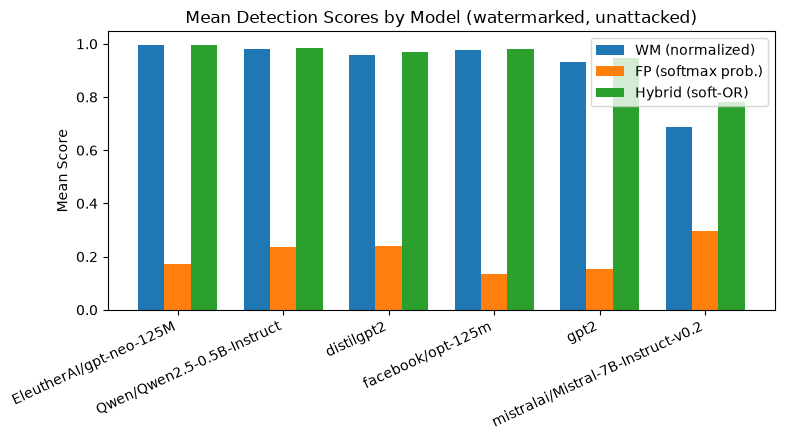

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

wm_none = all_df[(all_df["is_watermarked"] == True) & (all_df["attack"] == "none")]
summary = wm_none.groupby("model_name").agg(
    norm_wm=("norm_wm", "mean"),
    norm_fp=("norm_fp", "mean"),
    fused_mean=("fused_score", "mean"),
    latency_ms=("latency_ms", "mean"),
).reset_index()

plt.figure(figsize=(8, 4.5))
x = np.arange(len(summary))
w = 0.25
plt.bar(x - w, summary["norm_wm"], width=w, label="WM (normalized)")
plt.bar(x, summary["norm_fp"], width=w, label="FP (softmax prob.)")
plt.bar(x + w, summary["fused_mean"], width=w, label="Hybrid (soft-OR)")
plt.xticks(x, summary["model_name"], rotation=25, ha="right")
plt.ylabel("Mean Score")
plt.title("Mean Detection Scores by Model (watermarked, unattacked)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "fig1_mean_scores_by_model.png", dpi=300)
plt.show()

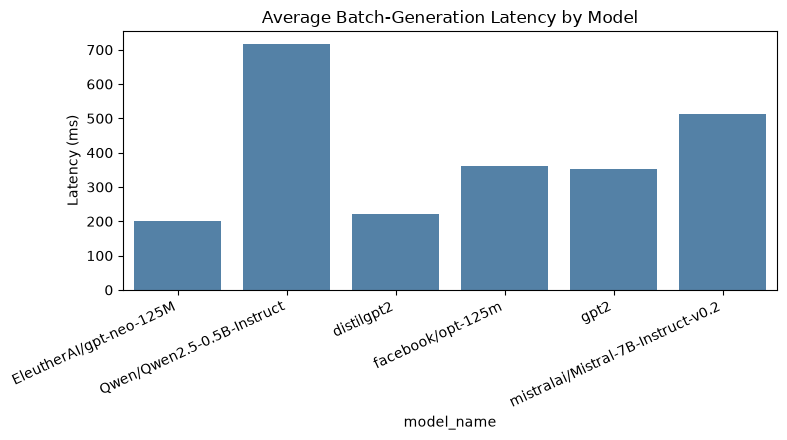

In [18]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=summary, x="model_name", y="latency_ms", color="steelblue")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Latency (ms)")
plt.title("Average Batch-Generation Latency by Model")
plt.tight_layout()
plt.savefig(OUTDIR / "fig2_latency_by_model.png", dpi=300)
plt.show()

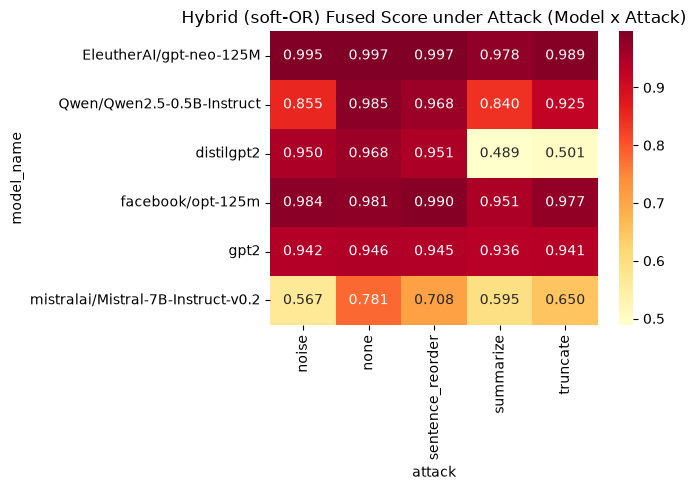

In [19]:
wm_all_attacks = all_df[all_df["is_watermarked"] == True]
pivot = wm_all_attacks.pivot_table(index="model_name", columns="attack", values="fused_score", aggfunc="mean")
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Hybrid (soft-OR) Fused Score under Attack (Model x Attack)")
plt.tight_layout()
plt.savefig(OUTDIR / "fig3_heatmap_model_attack.png", dpi=300)
plt.show()

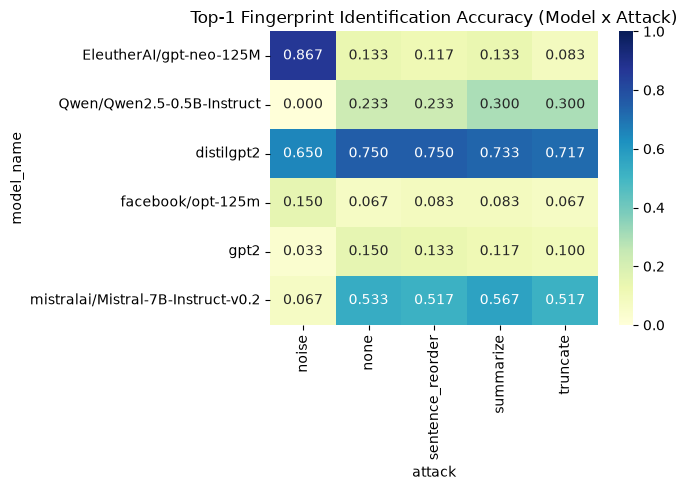

In [20]:
pivot_top1 = wm_all_attacks.pivot_table(index="model_name", columns="attack", values="fp_dec", aggfunc="mean")
plt.figure(figsize=(7, 5))
sns.heatmap(pivot_top1, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Top-1 Fingerprint Identification Accuracy (Model x Attack)")
plt.tight_layout()
plt.savefig(OUTDIR / "fig4_top1_accuracy_heatmap.png", dpi=300)
plt.show()

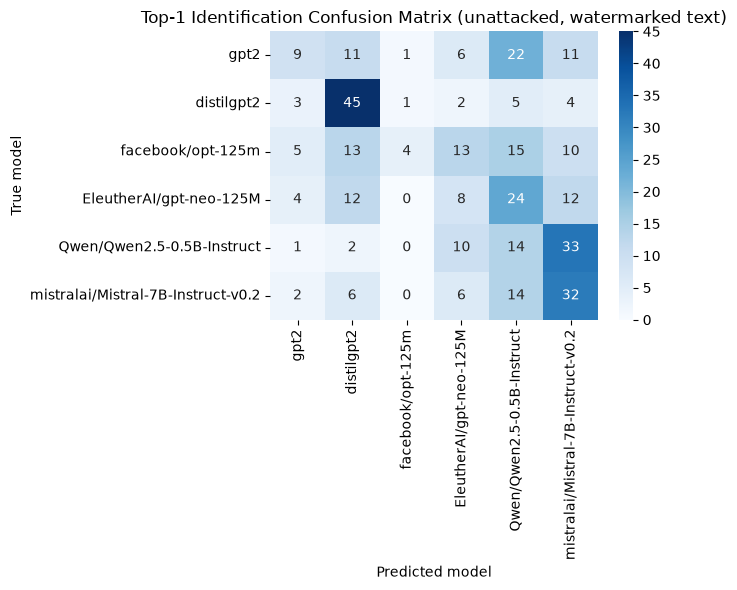

top1_pred_model,gpt2,distilgpt2,facebook/opt-125m,EleutherAI/gpt-neo-125M,Qwen/Qwen2.5-0.5B-Instruct,mistralai/Mistral-7B-Instruct-v0.2
model_name,,,,,,
gpt2,9,11,1,6,22,11
distilgpt2,3,45,1,2,5,4
facebook/opt-125m,5,13,4,13,15,10
EleutherAI/gpt-neo-125M,4,12,0,8,24,12
Qwen/Qwen2.5-0.5B-Instruct,1,2,0,10,14,33
mistralai/Mistral-7B-Instruct-v0.2,2,6,0,6,14,32


In [21]:
none_wm = all_df[(all_df["attack"] == "none") & (all_df["is_watermarked"] == True)]
confusion = pd.crosstab(none_wm["model_name"], none_wm["top1_pred_model"])
confusion = confusion.reindex(index=MODELS, columns=MODELS, fill_value=0)

plt.figure(figsize=(7, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Top-1 Identification Confusion Matrix (unattacked, watermarked text)")
plt.ylabel("True model")
plt.xlabel("Predicted model")
plt.tight_layout()
plt.savefig(OUTDIR / "fig5_confusion_matrix.png", dpi=300)
plt.show()
confusion

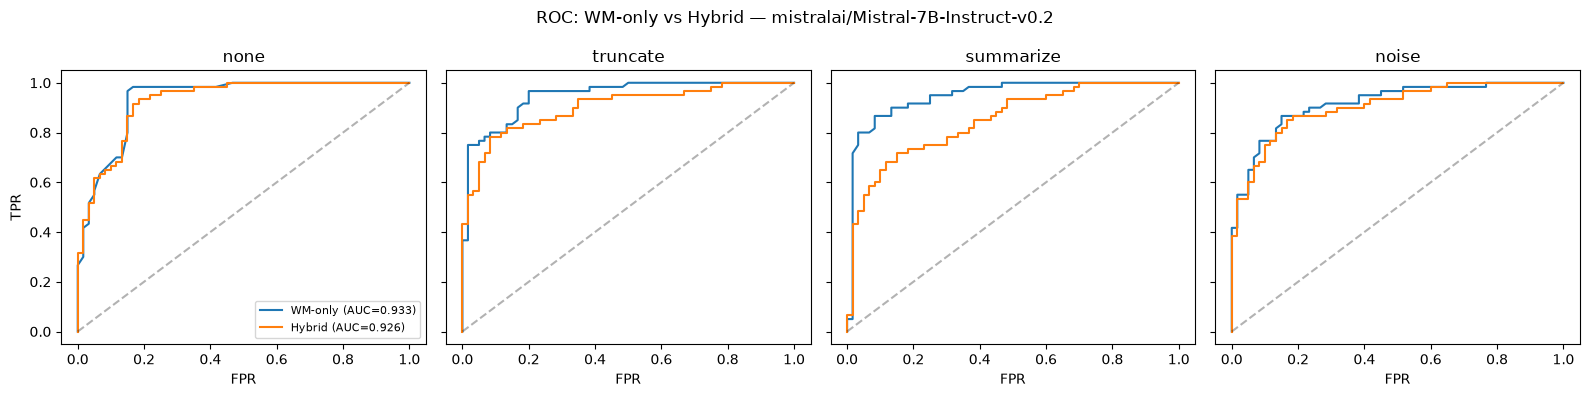

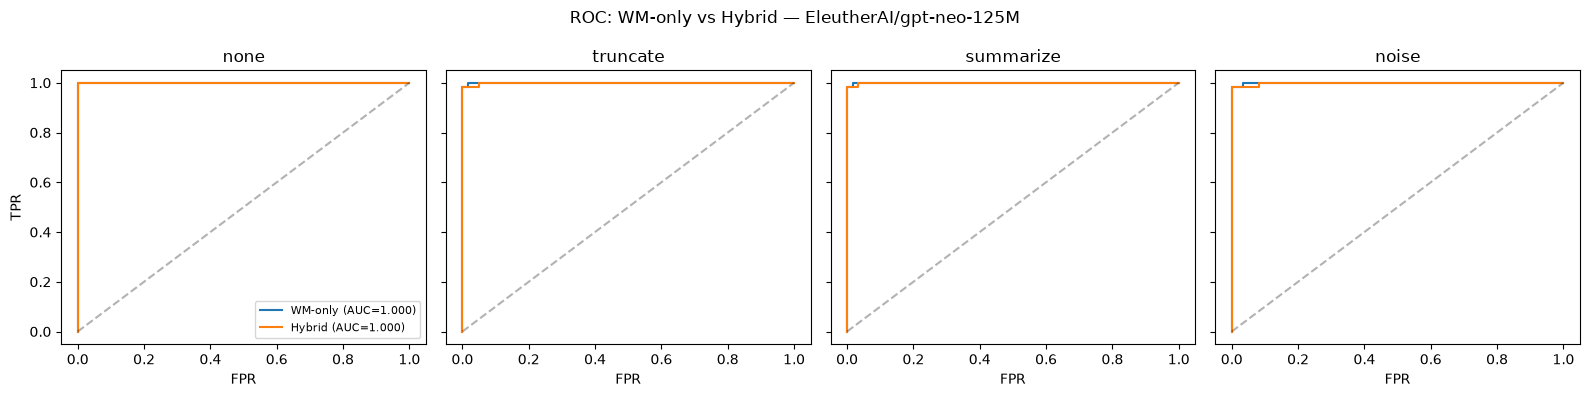

In [22]:
from sklearn.metrics import roc_curve

def plot_roc_panel(df, model_name, attacks, metrics=("wm_z", "fused_score"),
                    labels=("WM-only", "Hybrid")):
    fig, axes = plt.subplots(1, len(attacks), figsize=(4*len(attacks), 4), sharey=True)
    if len(attacks) == 1:
        axes = [axes]
    for ax, attack in zip(axes, attacks):
        g = df[(df["model_name"] == model_name) & (df["attack"] == attack)]
        y = g["is_watermarked"].astype(int).values
        for metric, label in zip(metrics, labels):
            fpr, tpr, _ = roc_curve(y, g[metric].values)
            auc = roc_auc_score(y, g[metric].values)
            ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
        ax.set_title(attack)
        ax.set_xlabel("FPR")
    axes[0].set_ylabel("TPR")
    axes[0].legend(fontsize=8)
    fig.suptitle(f"ROC: WM-only vs Hybrid — {model_name}")
    plt.tight_layout()
    plt.savefig(OUTDIR / f"fig6_roc_{model_name.replace('/','_')}.png", dpi=300)
    plt.show()

# pick your two most informative models based on Table B
plot_roc_panel(all_df, "mistralai/Mistral-7B-Instruct-v0.2",
                ["none", "truncate", "summarize", "noise"])
plot_roc_panel(all_df, "EleutherAI/gpt-neo-125M",
                ["none", "truncate", "summarize", "noise"])

In [ ]:

import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

PROBES_EXPANDED = [
    "Describe how to brew tea briefly.",
    "Explain a short analogy about clouds.",
    "Write three short sentences about cooking rice.",
    "What's a good way to organize a small bookshelf?",
    "Give a quick tip for keeping houseplants alive.",
    "Describe the sound of rain on a roof.",
    "Explain why bicycles stay upright while moving.",
    "Write two sentences about the smell of fresh bread.",
    "What makes a good paper airplane?",
    "Briefly describe how a compass works.",
]

def generate_single_greedy(prompt, model, tokenizer, max_new_tokens=64):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                          pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)


def build_stabilized_galleries(probes=PROBES_EXPANDED):
    """Deterministic (greedy) decoding removes gallery-build randomness entirely --
    re-running this function twice should give identical galleries."""
    embedder_local = SentenceTransformer("all-MiniLM-L6-v2")
    galleries = {}
    for m in MODELS:
        print(f"Building stabilized gallery for {m}...")
        model, tokenizer = load_model(m)
        responses = [generate_single_greedy(p, model, tokenizer) for p in probes]
        embs = embedder_local.encode(responses, normalize_embeddings=True)  # (n_probes, dim)
        galleries[m] = embs
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return galleries, embedder_local


def score_with_centering(text, galleries_per_probe, embedder, center, true_model_name, temperature=0.05):
    """Per-probe similarity voting AND mean-centering combined."""
    model_names = list(galleries_per_probe.keys())
    gallery_tensor = np.stack([galleries_per_probe[m] for m in model_names])  # (n_models, n_probes, dim)
    gallery_tensor_c = gallery_tensor - center
    gallery_tensor_c = gallery_tensor_c / np.linalg.norm(gallery_tensor_c, axis=-1, keepdims=True)

    emb = embedder.encode(text, normalize_embeddings=True)
    emb_c = emb - center
    emb_c = emb_c / np.linalg.norm(emb_c)

    sims_per_probe = gallery_tensor_c @ emb_c   # (n_models, n_probes)
    sims = sims_per_probe.mean(axis=1)          # per-probe vote
    logits = sims / temperature
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()

    true_idx = model_names.index(true_model_name)
    top1_idx = int(np.argmax(sims))
    return {
        "fp_score_fixed": float(probs[true_idx]),
        "fp_dec_fixed": int(top1_idx == true_idx),
        "top1_pred_model_fixed": model_names[top1_idx],
    }


# --- Step 1: build the stabilized galleries ONCE (deterministic -> reproducible) ---
galleries_fixed, embedder = build_stabilized_galleries()
center = np.stack(list(galleries_fixed.values())).reshape(-1, 384).mean(axis=0)  # 384 = MiniLM dim

# --- Step 2: reproducibility check -- rebuild and confirm it's identical ---
galleries_fixed_repeat, _ = build_stabilized_galleries()
max_diff = max(
    np.abs(galleries_fixed[m] - galleries_fixed_repeat[m]).max() for m in MODELS
)
print(f"Max embedding difference between two gallery builds: {max_diff:.6f}")
print("(should be ~0.0 with greedy decoding -- if not, generation isn't actually deterministic on your setup)")

# --- Step 3: rescore all existing rows (fast, no LLM needed, just embeddings) ---
records = []
for row in tqdm(all_df.itertuples(index=False), total=len(all_df)):
    records.append(score_with_centering(row.attacked_text, galleries_fixed, embedder, center, row.model_name))
fixed_df = pd.DataFrame(records)
all_df_fixed = pd.concat([all_df.reset_index(drop=True), fixed_df], axis=1)

all_df_fixed["norm_fp_fixed"] = all_df_fixed["fp_score_fixed"].clip(0, 1)
all_df_fixed["fused_score_fixed"] = (
    all_df_fixed["norm_wm"] + all_df_fixed["norm_fp_fixed"]
    - all_df_fixed["norm_wm"] * all_df_fixed["norm_fp_fixed"]
)

none_wm_fixed = all_df_fixed[(all_df_fixed.attack == "none") & (all_df_fixed.is_watermarked == True)]
print("\nFixed (centered + per-probe-voted + stabilized) top-1 prediction share:")
print((none_wm_fixed["top1_pred_model_fixed"].value_counts(normalize=True) * 100).round(1))
print("(fair share is 16.7% each -- report this table in the paper regardless of outcome)")

# --- Step 4: top-1 accuracy per model with the fix, for Table II ---
top1_acc_fixed = (
    all_df_fixed.groupby(["model_name", "attack"])["fp_dec_fixed"].mean().reset_index()
)
print("\nPer-model top-1 accuracy summary (fixed):")
print(top1_acc_fixed.groupby("model_name")["fp_dec_fixed"].agg(["min", "max", "mean"]).round(3))

all_df_fixed.to_csv("all_results_fingerprint_fixed.csv", index=False)

PARAPHRASE_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"

def paraphrase_text(text, model, tokenizer, max_new_tokens=150):
    prompt = (
        "Paraphrase the following passage. Keep the meaning the same but "
        "use different words and sentence structure. Only output the "
        f"paraphrased passage, nothing else.\n\nPassage: {text}\n\nParaphrase:"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=True,
                          temperature=0.7, pad_token_id=tokenizer.pad_token_id)
    result = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return result.strip()

print(f"\nLoading {PARAPHRASE_MODEL} for paraphrase attack...")
para_model, para_tokenizer = load_model(PARAPHRASE_MODEL)

raw_rows = all_df[all_df["attack"] == "none"][
    ["model_name", "sample_id", "is_watermarked", "attacked_text", "wm_z"]
].copy()
raw_rows = raw_rows[raw_rows["attacked_text"].fillna("").str.split().str.len() >= 10]  # skip empties

print(f"Paraphrasing {len(raw_rows)} raw generations (this is the slow step -- budget "
      f"real time for it, especially if you run it on all six models' outputs)...")

paraphrased_texts = []
for row in tqdm(raw_rows.itertuples(index=False), total=len(raw_rows)):
    paraphrased_texts.append(paraphrase_text(row.attacked_text, para_model, para_tokenizer))
raw_rows["paraphrased_text"] = paraphrased_texts

del para_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Re-score watermark detection on the paraphrased text.
# You need access to each model's watermark detector object (built in Cell 12/13
# of your notebook) -- reuse `detectors[model_name]` here.
def rescore_watermark(text, model_name, detectors):
    det = detectors[model_name]
    result = det.detect(text)   # adjust to your actual detector's method signature
    return result["z_score"], result["p_value"]

wm_records = []
for row in tqdm(raw_rows.itertuples(index=False), total=len(raw_rows)):
    z, p = rescore_watermark(row.paraphrased_text, row.model_name, detectors)
    wm_records.append({"wm_z_paraphrased": z, "wm_p_paraphrased": p})
raw_rows = pd.concat([raw_rows.reset_index(drop=True), pd.DataFrame(wm_records)], axis=1)

# Re-score fingerprint on the paraphrased text using whichever gallery
# (original or fixed) you've decided to use going forward.
fp_records = []
for row in tqdm(raw_rows.itertuples(index=False), total=len(raw_rows)):
    fp_records.append(score_with_centering(row.paraphrased_text, galleries_fixed, embedder, center, row.model_name))
raw_rows = pd.concat([raw_rows.reset_index(drop=True), pd.DataFrame(fp_records)], axis=1)

raw_rows.to_csv("paraphrase_attack_results.csv", index=False)

# Compare watermark AUROC before vs. after paraphrase, per model.
from sklearn.metrics import roc_auc_score
print("\nWatermark AUROC under paraphrase attack, by model:")
for m in raw_rows["model_name"].unique():
    sub = raw_rows[raw_rows.model_name == m]
    if sub["is_watermarked"].nunique() < 2 or len(sub) < 4:
        continue
    auroc_before = roc_auc_score(sub["is_watermarked"], sub["wm_z"])
    auroc_after = roc_auc_score(sub["is_watermarked"], sub["wm_z_paraphrased"])
    print(f"  {m}: unattacked AUROC={auroc_before:.3f}  ->  paraphrased AUROC={auroc_after:.3f}")

# THIS is the table/figure that actually tests the hybrid's core claim:
# wherever wm AUROC drops meaningfully under paraphrase, check whether
# fp_dec_fixed / hybrid AUROC holds up better than wm alone on those same rows.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Building stabilized gallery for gpt2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Building stabilized gallery for distilgpt2...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...


Fixed (centered + per-probe-voted + stabilized) top-1 prediction share:
top1_pred_model_fixed
mistralai/Mistral-7B-Instruct-v0.2    32.2
Qwen/Qwen2.5-0.5B-Instruct            29.7
distilgpt2                            12.5
gpt2                                  11.4
EleutherAI/gpt-neo-125M                8.6
facebook/opt-125m                      5.6
Name: proportion, dtype: float64
(fair share is 16.7% each -- report this table in the paper regardless of outcome)

Per-model top-1 accuracy summary (fixed):
                                      min    max   mean
model_name                                             
EleutherAI/gpt-neo-125M             0.150  0.175  0.162
Qwen/Qwen2.5-0.5B-Instruct          0.067  0.450  0.337
distilgpt2                          0.592  0.617  0.598
facebook/opt-125m                   0.125  0.708  0.250
gpt2                                0.083  0.158  0.127
mistralai/Mistral-7B-Instruct-v0.2  0.158  0.575  0.480

Loading mistralai/Mistral-7B-Instruct-v

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Paraphrasing 640 raw generations (this is the slow step -- budget real time for it, especially if you run it on all six models' outputs)...


  0%|                                                   | 0/640 [00:00<?, ?it/s]


NameError: name 'detectors' is not defined

In [ ]:
# match your actual import

GAMMA = 0.5
SEEDING_SCHEME = "simple_1"  # <-- MUST match whatever you used for generation.
                              #     Common values: "simple_1", "selfhash", "lefthash".
                              #     Check the cell where you built the
                              #     WatermarkLogitsProcessor for generation --
                              #     use the exact same value here.

detectors = {}
for m in MODELS:
    _, tokenizer = load_model(m)  # only need the tokenizer, not the full model,
                                   # if your detector doesn't need model weights
    detectors[m] = WatermarkDetector(
        vocab=list(tokenizer.get_vocab().values()),
        gamma=GAMMA,
        seeding_scheme=SEEDING_SCHEME,
        device="cpu",
        tokenizer=tokenizer,
        z_threshold=4.0,
        normalizers=[],
        ignore_repeated_ngrams=True,
    )

# --- VALIDATION: don't trust this until it reproduces YOUR existing numbers ---
# Take 5 known rows from the 'none' attack (already scored, wm_z already in
# all_df) and check the reconstructed detector gives the same z-score.
check = all_df[(all_df.attack == "none") & (all_df.is_watermarked == True)].sample(5, random_state=0)
print("Validation -- reconstructed detector vs. your original wm_z:")
max_abs_diff = 0
for row in check.itertuples(index=False):
    result = detectors[row.model_name].detect(row.attacked_text)
    z_new = result["z_score"]
    diff = abs(z_new - row.wm_z)
    max_abs_diff = max(max_abs_diff, diff)
    print(f"  {row.model_name}: original z={row.wm_z:.3f}, reconstructed z={z_new:.3f}, diff={diff:.3f}")

if max_abs_diff > 0.05:
    print("\n*** MISMATCH -- do not trust this detector for the paraphrase results. ***")
    print("Go to the cell in your notebook where wm_z is computed inside your main")
    print("experiment loop (run_robustness_experiment), copy the exact detector")
    print("construction + .detect(...) call from there, and use that instead of")
    print("the reconstruction above.")
else:
    print("\nMatch confirmed -- safe to use `detectors` for the paraphrase attack rescoring.")

# Once validated, re-run the wm_records loop from Part B using this `detectors` dict:
def rescore_watermark(text, model_name, detectors):
    result = detectors[model_name].detect(text)
    return result["z_score"], result["p_value"]

wm_records = []
for row in tqdm(raw_rows.itertuples(index=False), total=len(raw_rows)):
    z, p = rescore_watermark(row.paraphrased_text, row.model_name, detectors)
    wm_records.append({"wm_z_paraphrased": z, "wm_p_paraphrased": p})
raw_rows = pd.concat([raw_rows.reset_index(drop=True), pd.DataFrame(wm_records)], axis=1)